### Пункт 1 - подготовка корпуса текста

В качестве текстового корпуса использован роман Ф. М. Достоевского «Преступление и наказание». Функция `preprocess_text` выполняет токенизацию, приводит слова к нижнему регистру, удаляет знаки препинания и другие неалфавитные токены, а также исключает русские стоп-слова. Ресурсы `punkt_tab` и `stopwords` загружаются только при первом запуске.

In [20]:
from pathlib import Path


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

BASE_DIR = Path.cwd()
NLTK_DATA_DIR = BASE_DIR / "nltk_data"
TEXT_PATH = BASE_DIR / "data" / "text.txt"

nltk.data.path.insert(0, str(NLTK_DATA_DIR))

# Выполнить только при первом запуске, чтобы скачать необходимые ресурсы
# nltk.download("punkt_tab", download_dir=str(NLTK_DATA_DIR))
# nltk.download("stopwords", download_dir=str(NLTK_DATA_DIR))

RU_STOPWORDS = set(stopwords.words("russian"))


def preprocess_text(text):
    tokens = word_tokenize(text, language="russian")

    return [
        word.lower()
        for word in tokens
        if word.isalpha() and word.lower() not in RU_STOPWORDS
    ]


with TEXT_PATH.open("r", encoding="utf-8") as file:
    text = file.read()

processed_text = preprocess_text(text)

print(f"Рабочая папка: {BASE_DIR}")
print(f"Всего токенов: {len(processed_text)}")
print(f"Первые 20 токенов: {processed_text[:20]}")

Рабочая папка: /home/artem/index-lab-2026
Всего токенов: 88381
Первые 20 токенов: ['преступление', 'наказание', 'автор', 'фёдор', 'михайлович', 'достоевский', 'экспортировано', 'викитеки', 'сентября', 'часть', 'первая', 'глава', 'i', 'глава', 'ii', 'глава', 'iii', 'глава', 'iv', 'глава']


In [ ]:
def sentence_tokenize(text):
    return nltk.sent_tokenize(text, language="russian")

def word_tokenize(text):
    return nltk.word_tokenize(text, language="russian")

print(f"Всего предложений: {len(sentence_tokenize(text))}")
print(f"Первые 5 слов: {word_tokenize(text)[:5]}")

Всего предложений: 13493
Первые 5 слов: ['Преступление', 'и', 'наказание', 'автор', 'Фёдор']


**Вывод по пункту 1.** После предобработки получено 88 381 токен из 13 493 предложений. Все отобранные токены приведены к нижнему регистру, не содержат пунктуации и очищены от русских стоп-слов. Полученный корпус подготовлен для обучения векторных моделей.

### Пункт 2 - обучение векторных моделей

На подготовленном корпусе обучаются две модели Word2Vec: Skip-gram и CBOW. Для их корректного сравнения используется одинаковая базовая конфигурация: `vector_size=100`, `window=5` и `min_count=5`; различается только параметр `sg`. Параметр `vector_size` задаёт размерность вектора слова, `window` — ширину учитываемого контекста, а `min_count` — минимальную частоту слова для включения в словарь. Влияние изменения этих параметров оценивается по результатам поиска похожих слов, решения аналогий и визуализации в последующих пунктах.

In [21]:
from gensim.models import Word2Vec

# sentences — корпус для обучения. Здесь processed_text содержит список токенов.
# vector_size — размер вектора каждого слова. Каждое слово представляется 100 числами.
# window — размер контекстного окна: до 5 слов слева и справа от текущего слова.
# min_count — минимальная частота слова. Слова, встретившиеся менее 5 раз, не включаются в словарь модели.
# workers — количество потоков процессора, используемых при обучении.
# sg — выбор алгоритма: 1 — Skip-gram, 0 — CBOW.

# Обучение модели Skip-gram
model_sg = Word2Vec(
    sentences=[processed_text],
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    workers=4
)
# Обучение модели CBOW
model_cbow = Word2Vec(
    sentences=[processed_text],
    vector_size=100, 
    window=5,
    min_count=5,
    sg=0,
    workers=4
)

print(len(model_sg.wv))
print(model_sg.wv.index_to_key[:20])

3284
['это', 'раскольников', 'очень', 'соня', 'человек', 'разумихин', 'петрович', 'тебе', 'время', 'дело', 'тотчас', 'минуту', 'ивановна', 'сказал', 'мог', 'стало', 'кажется', 'стал', 'сказать', 'точно']


**Вывод по пункту 2.** Обе модели успешно обучены на одном корпусе; размер их словаря при базовых параметрах составляет 3 284 слова. Одинаковые параметры позволяют сравнивать именно алгоритмы Skip-gram и CBOW. При изменении `vector_size`, `window` или `min_count` переобучаются векторы и словарь, поэтому закономерно меняются результаты всех последующих пунктов. Сравнение таких изменений приводится в отчёте на примере ближайших слов, аналогий и t-SNE-визуализации.

### Пункт 3 - загрузка готовой модели

Для сравнения с собственными моделями через `gensim.downloader` загружается предобученная русскоязычная модель `word2vec-ruscorpora-300`. Файлы модели сохраняются в каталоге `models/pretrained`. В её словаре к словам добавлены обозначения частей речи, например `_NOUN` для существительных.

In [13]:
import os

PRETRAINED_MODELS_DIR = BASE_DIR / "models" / "pretrained"
PRETRAINED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

os.environ["GENSIM_DATA_DIR"] = str(PRETRAINED_MODELS_DIR)

import gensim.downloader as api
pretrained_model = api.load("word2vec-ruscorpora-300")

[==================================================] 100.0% 198.8/198.8MB downloaded


**Вывод по пункту 3.** Предобученная модель успешно загружена и готова к поиску ближайших слов, решению аналогий и визуализации. Использование модели RusCorpora вместо англоязычной Google News оправдано тем, что исследуемый корпус и выбранные слова представлены на русском языке.

### Пункт 4 - поиск схожих слов

Для слов «книга», «дом», «факт», «топор» и «студент» находятся по десять ближайших соседей в моделях Skip-gram, CBOW и RusCorpora. Метод `most_similar` ранжирует слова по косинусному сходству: чем ближе коэффициент к 1, тем ближе направления соответствующих векторов.

In [14]:
print("Похожие слова в модели Skip-gram:")
for word in ["книга", "дом", "факт", "топор", "студент"]:
    key = f"{word}"

    if key in model_sg.wv:
        print(word, model_sg.wv.most_similar(key, topn=10))

print(f'\nПохожие слова в модели CBOW:')
for word in ["книга", "дом", "факт", "топор", "студент"]:
    key = f"{word}"

    if key in model_cbow.wv:
        print(word, model_cbow.wv.most_similar(key, topn=10))

print(f'\nПохожие слова в модели pretrained_model:')
for word in ["книга", "дом", "факт", "топор", "студент"]:
    key = f"{word}_NOUN"

    if key in pretrained_model:
        print(word, pretrained_model.most_similar(key, topn=10))

Похожие слова в модели Skip-gram:
книга [('мешается', 0.3065466284751892), ('ложь', 0.296590119600296), ('сторон', 0.29544597864151), ('наедине', 0.2873552441596985), ('настоящий', 0.2683860957622528), ('похоронах', 0.2633524537086487), ('провидение', 0.2602137625217438), ('отыскивать', 0.2541557252407074), ('находится', 0.2539445459842682), ('знайте', 0.2533286213874817)]
дом [('хотя', 0.9966325759887695), ('дома', 0.9964274168014526), ('это', 0.9963259100914001), ('стал', 0.9962558150291443), ('очень', 0.9962067008018494), ('минуту', 0.9961925148963928), ('комнату', 0.9961303472518921), ('дело', 0.9960797429084778), ('взял', 0.9960510730743408), ('руки', 0.9960041642189026)]
факт [('ложь', 0.35011035203933716), ('меры', 0.3368413746356964), ('семеновне', 0.33074870705604553), ('сестрицы', 0.2918166518211365), ('рассказывает', 0.28371450304985046), ('убью', 0.27857133746147156), ('дали', 0.265621542930603), ('обоях', 0.2500986158847809), ('убеждений', 0.24403098225593567), ('ослабел',

**Вывод по пункту 4.** Результаты моделей заметно различаются. Предобученная RusCorpora выдаёт наиболее понятные тематические связи: для слова «книга» найдены «книжка», «рукопись» и «издание», для «топора» - «пила», «нож» и «молоток», для «студента» - «преподаватель», «университет» и «аспирант». Собственные модели чаще отражают контекст конкретного произведения, а не общее значение слова. У Skip-gram для некоторых слабо связанных слов наблюдаются значения сходства около 0,99, что указывает на недостаток разнообразных обучающих контекстов в корпусе одной книги. CBOW показывает более умеренные коэффициенты, однако её соседи также не всегда семантически точны. Следовательно, размер и разнообразие корпуса, выбранный алгоритм и параметры обучения существенно влияют на качество ближайших слов.

### Пункт 5 - решение аналогий

Семантическая аналогия вычисляется с помощью векторной операции вида `A + B − C`. Для предобученной модели проверяются комбинации «рассказчик + история − человек» и «интеллект + программист − человек». Дополнительно для собственных моделей исследуется результат вычитания одного понятия из другого.

In [15]:
result = pretrained_model.most_similar(positive=["рассказчик_NOUN", "история_NOUN"], negative=['человек_NOUN'], topn=2)
print(result)
result = pretrained_model.most_similar(positive=["интеллект_NOUN", "программист_NOUN"], negative=['человек_NOUN'], topn=2)
print(result)

[('повествование_NOUN', 0.5843981504440308), ('рассказ_NOUN', 0.5307407975196838)]
[('компьютер_NOUN', 0.5256171822547913), ('компьютерный_ADJ', 0.5068411231040955)]


In [16]:
result_sg = model_cbow.wv.most_similar(positive=["раскольников"], negative=["человек"], topn=2)
print(result_sg)
result_sg = model_cbow.wv.most_similar(positive=["кровать"], negative=["дом"], topn=2)
print(result_sg)

[('сумел', 0.3446038067340851), ('слово', 0.3120780885219574)]
[('дверей', 0.31560495495796204), ('покое', 0.3050439655780792)]


In [17]:
result_sg = model_sg.wv.most_similar(positive=["раскольников"], negative=["человек"], topn=2)
print(result_sg)
result_sg = model_sg.wv.most_similar(positive=["кровать"], negative=["дом"], topn=2)
print(result_sg)

[('сумел', 0.2952103018760681), ('раздражать', 0.25396230816841125)]
[('вдумчиво', 0.3574838936328888), ('мостовой', 0.2596786320209503)]


**Вывод по пункту 5.** Для операции «рассказчик + история − человек» предобученная модель получила слова «повествование» (0,584) и «рассказ» (0,531), а для операции «интеллект + программист − человек» - «компьютер» (0,526) и «компьютерный» (0,507). Полученные ответы семантически объяснимы и показывают, что предобученная модель частично сохраняет смысловые отношения между понятиями. Результаты собственных моделей интерпретируются хуже: небольшой корпус одной книги содержит недостаточно разнообразных примеров для устойчивого кодирования сложных отношений. Кроме того, приведённые для них операции имеют вид `A − B` и являются дополнительным исследованием направлений векторов, а не полной аналогией `A + B − C`.

### Пункт 6 - визуализация векторов

Для визуализации выбраны 20 слов, присутствующих во всех трёх моделях: 10 слов категории «Люди» и 10 слов категории «Места и предметы». Их нормализованные векторы преобразуются алгоритмом t-SNE из 100 или 300 измерений в двумерное пространство, после чего для каждой модели строится отдельная диаграмма рассеяния.

Люди: ['человек', 'женщина', 'мать', 'отец', 'брат', 'сестра', 'девушка', 'жена', 'сын', 'господин']
Места и предметы: ['дом', 'комната', 'город', 'дверь', 'окно', 'стол', 'книга', 'письмо', 'деньги', 'квартира']


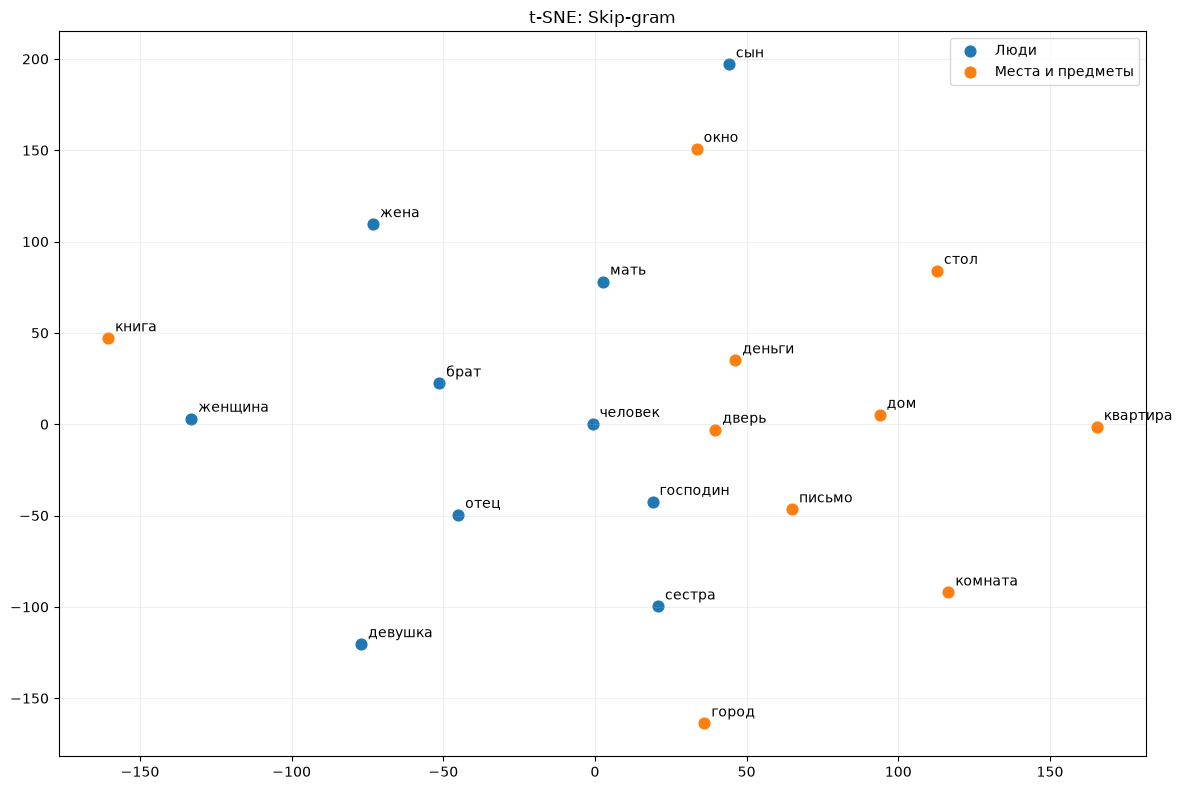

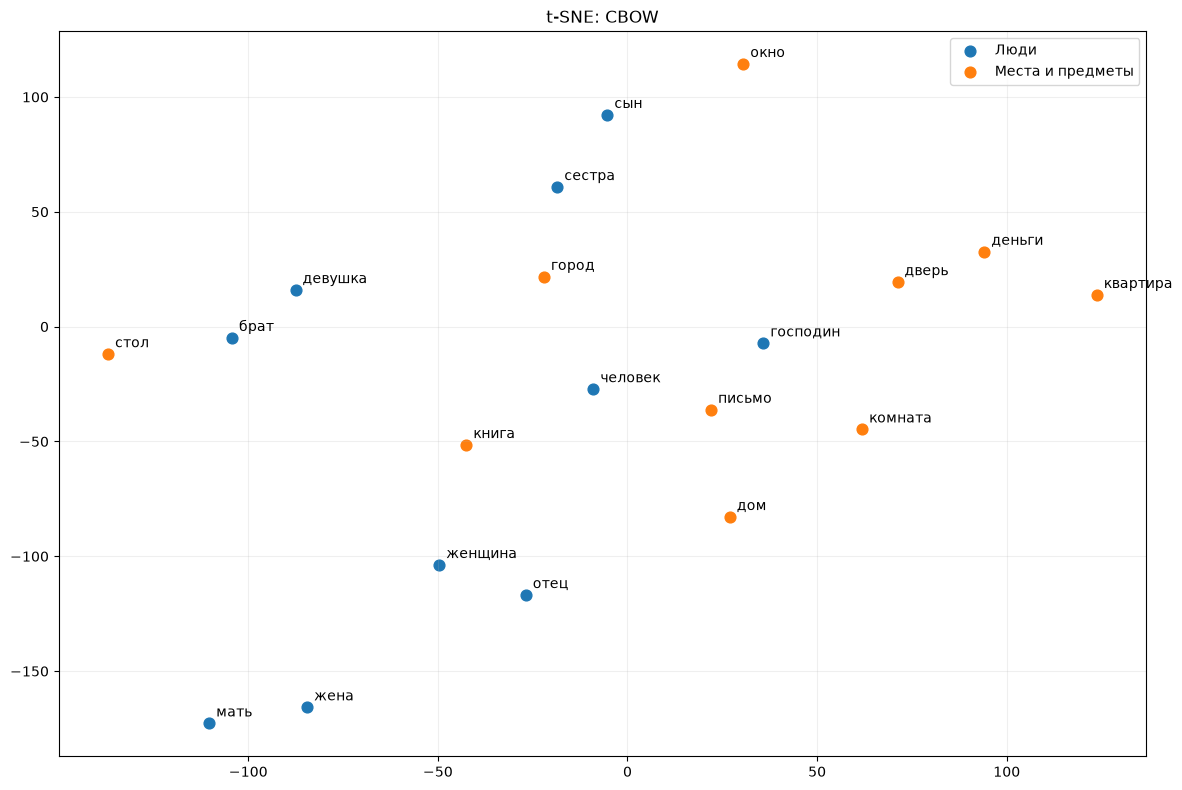

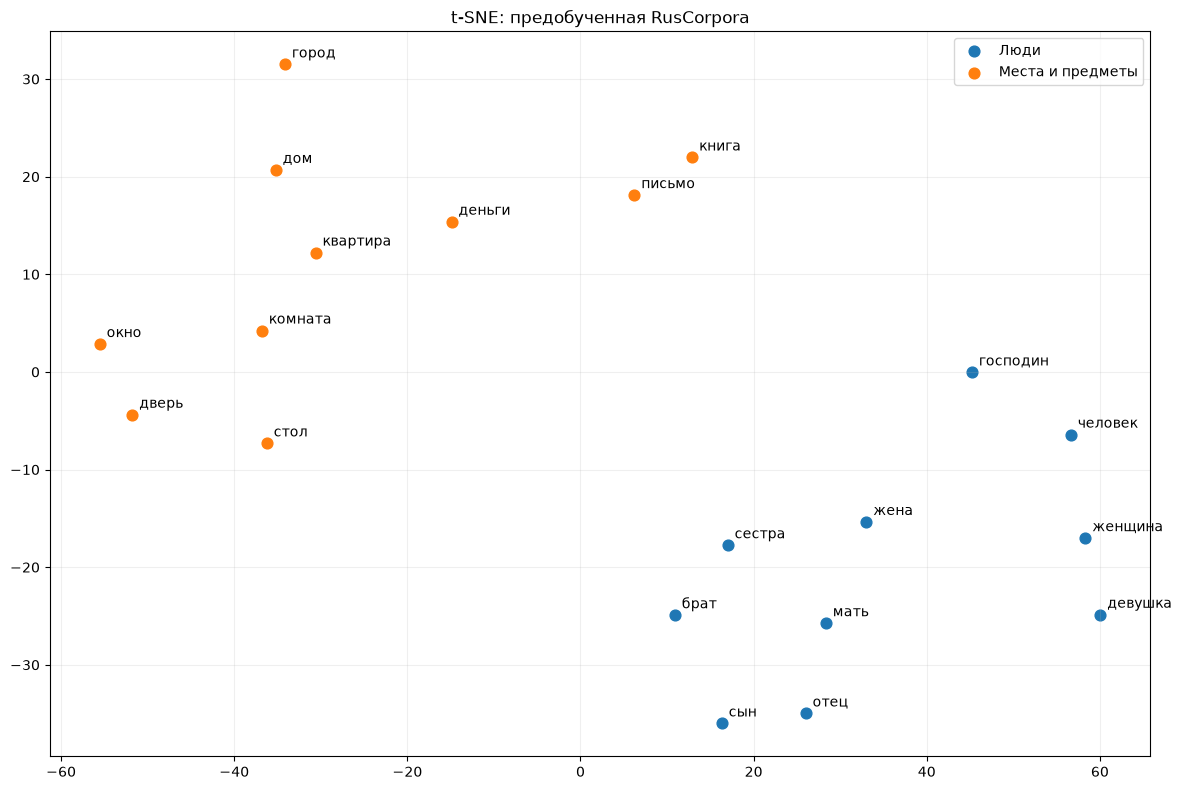

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE


# Кандидаты для первой темы: люди
people_candidates = [
    "человек",
    "мужчина",
    "женщина",
    "мать",
    "отец",
    "брат",
    "сестра",
    "девушка",
    "старик",
    "ребёнок",
    "жена",
    "сын",
    "господин",
    "чиновник",
    "доктор",
    "студент",
    "купец",
    "слуга",
]

# Кандидаты для второй темы: места и предметы
objects_candidates = [
    "дом",
    "комната",
    "улица",
    "город",
    "дверь",
    "окно",
    "стол",
    "книга",
    "письмо",
    "деньги",
    "квартира",
    "лестница",
    "двор",
    "бумага",
    "стул",
    "кухня",
    "площадь",
]


def is_available_in_all_models(word):
    return (
        word in model_sg.wv
        and word in model_cbow.wv
        and f"{word}_NOUN" in pretrained_model
    )


# Выбираем по 10 слов, присутствующих во всех трёх моделях
people = [
    word
    for word in people_candidates
    if is_available_in_all_models(word)
][:10]

objects = [
    word
    for word in objects_candidates
    if is_available_in_all_models(word)
][:10]


if len(people) < 10:
    raise ValueError(
        f"Недостаточно слов по теме «Люди»: найдено {len(people)}"
    )

if len(objects) < 10:
    raise ValueError(
        f"Недостаточно слов по теме «Места и предметы»: "
        f"найдено {len(objects)}"
    )


words = people + objects

print("Люди:", people)
print("Места и предметы:", objects)


def plot_tsne(model, keys, labels, title):
    vectors = np.array([
        model.get_vector(key, norm=True)
        for key in keys
    ])

    points = TSNE(
        n_components=2,
        perplexity=5,
        random_state=42,
        init="pca",
        learning_rate="auto",
    ).fit_transform(vectors)

    plt.figure(figsize=(12, 8))

    # Первые десять слов — люди
    plt.scatter(
        points[:10, 0],
        points[:10, 1],
        color="tab:blue",
        label="Люди",
        s=60,
    )

    # Следующие десять слов — места и предметы
    plt.scatter(
        points[10:, 0],
        points[10:, 1],
        color="tab:orange",
        label="Места и предметы",
        s=60,
    )

    for index, word in enumerate(labels):
        plt.annotate(
            word,
            (points[index, 0], points[index, 1]),
            xytext=(5, 5),
            textcoords="offset points",
        )

    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


# График собственной модели Skip-gram
plot_tsne(
    model=model_sg.wv,
    keys=words,
    labels=words,
    title="t-SNE: Skip-gram",
)


# График собственной модели CBOW
plot_tsne(
    model=model_cbow.wv,
    keys=words,
    labels=words,
    title="t-SNE: CBOW",
)


# В предобученной модели используются метки частей речи
pretrained_keys = [
    f"{word}_NOUN"
    for word in words
]

plot_tsne(
    model=pretrained_model,
    keys=pretrained_keys,
    labels=words,
    title="t-SNE: предобученная RusCorpora",
)

**Вывод по пункту 6.** На графиках собственных моделей Skip-gram и CBOW тематические группы разделяются лишь частично: некоторые слова категорий «Люди» и «Места и предметы» смешиваются. У предобученной модели RusCorpora разделение двух групп выражено заметнее. Причина состоит в том, что RusCorpora обучена на большом и разнообразном наборе русскоязычных текстов, тогда как собственные модели используют только одно художественное произведение. Следовательно, тематическая кластеризация присутствует во всех моделях в разной степени, но наиболее отчётливо она проявляется у предобученной модели. Следует учитывать, что t-SNE сохраняет прежде всего локальное соседство точек, поэтому расстояния между удалёнными кластерами нельзя интерпретировать как точные исходные расстояния между векторами.